1. IMPORTS & SETUP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Conv1D, MaxPooling1D, Flatten, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import joblib

2. DATA LOADING

In [ ]:
df = pd.read_csv('weatherAUS.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


3.  Data Analysis (EDA)

In [ ]:
# === 3.1 EDA PREPARATION ===
print("--- Data Info ---")
print(df.info())

# Chuyển đổi Date sang datetime để lấy tháng (cho biểu đồ số 3)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month

# Map dữ liệu Yes/No sang 1/0 để vẽ biểu đồ tương quan
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am   

In [ ]:
missing_props = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nTop Missing Columns (%):\n", missing_props.head(10))


Top Missing Columns (%):
 Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
dtype: float64


In [ ]:
# 3. Statistical Summary (Includes RainToday/RainTomorrow)
print("\n--- Summary Statistics (Numerical) ---")
print(df.describe())


--- Summary Statistics (Numerical) ---
                                Date        MinTemp        MaxTemp  \
count                         145460  143975.000000  144199.000000   
mean   2013-04-04 21:08:51.907053568      12.194034      23.221348   
min              2007-11-01 00:00:00      -8.500000      -4.800000   
25%              2011-01-11 00:00:00       7.600000      17.900000   
50%              2013-06-02 00:00:00      12.000000      22.600000   
75%              2015-06-14 00:00:00      16.900000      28.200000   
max              2017-06-25 00:00:00      33.900000      48.100000   
std                              NaN       6.398495       7.119049   

            Rainfall   Evaporation      Sunshine  WindGustSpeed  \
count  142199.000000  82670.000000  75625.000000  135197.000000   
mean        2.360918      5.468232      7.611178      40.035230   
min         0.000000      0.000000      0.000000       6.000000   
25%         0.000000      2.600000      4.800000      31.0000

In [ ]:
rain_counts = df['RainTomorrow'].value_counts(normalize=True)
print("\n--- RainTomorrow Distribution (Class Balance) ---")
print(rain_counts)


--- RainTomorrow Distribution (Class Balance) ---
RainTomorrow
0.0    0.775819
1.0    0.224181
Name: proportion, dtype: float64


FIGURE 1: Correlation Heatmap

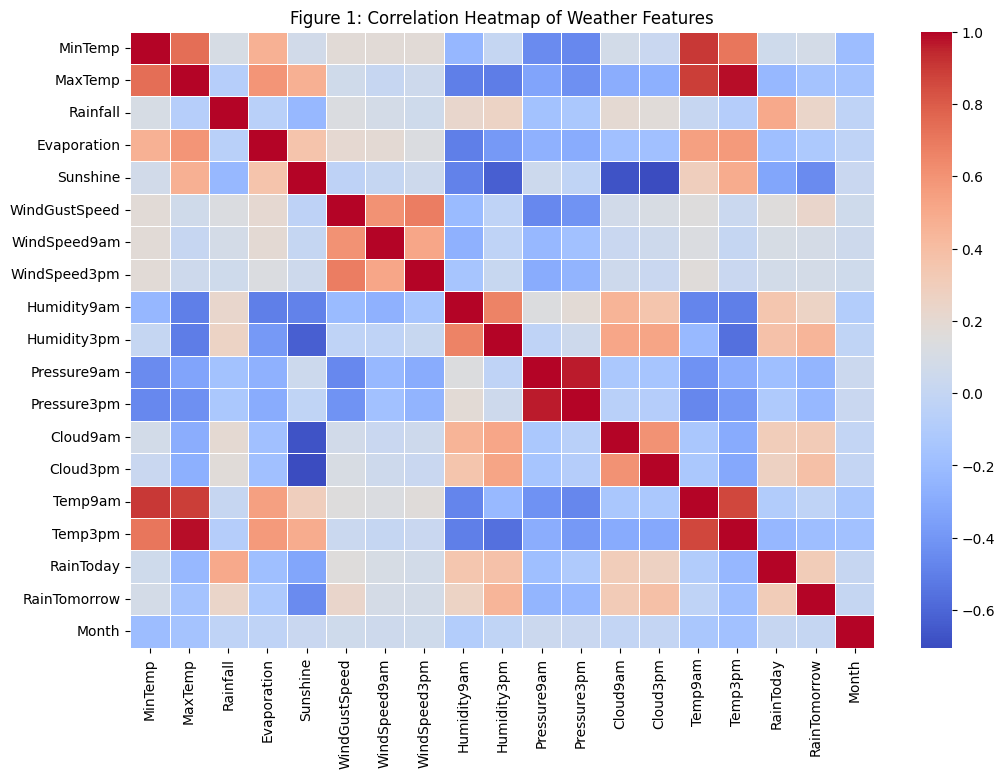

In [ ]:
# Xem tương quan giữa các biến số
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Figure 1: Correlation Heatmap of Weather Features")
plt.show()

FIGURE 2: Humidity vs Rain Tomorrow (Boxplot)

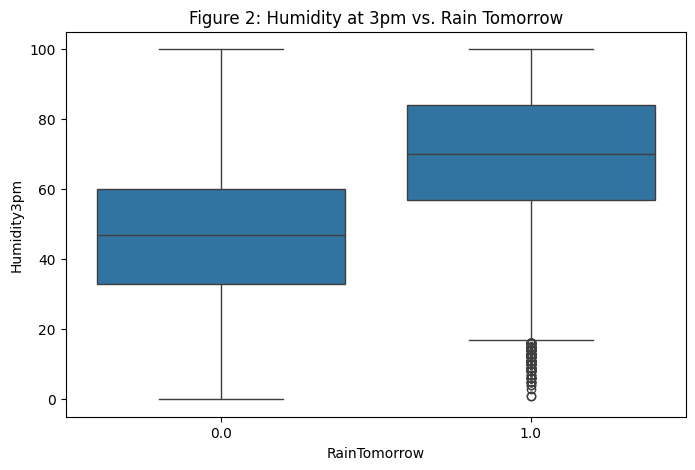

In [ ]:
# Độ ẩm lúc 3pm thường ảnh hưởng lớn đến việc mưa vào ngày mai
plt.figure(figsize=(8, 5))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.title("Figure 2: Humidity at 3pm vs. Rain Tomorrow")
plt.show()

FIGURE 3: Seasonal Trends (Rain Probability by Month)

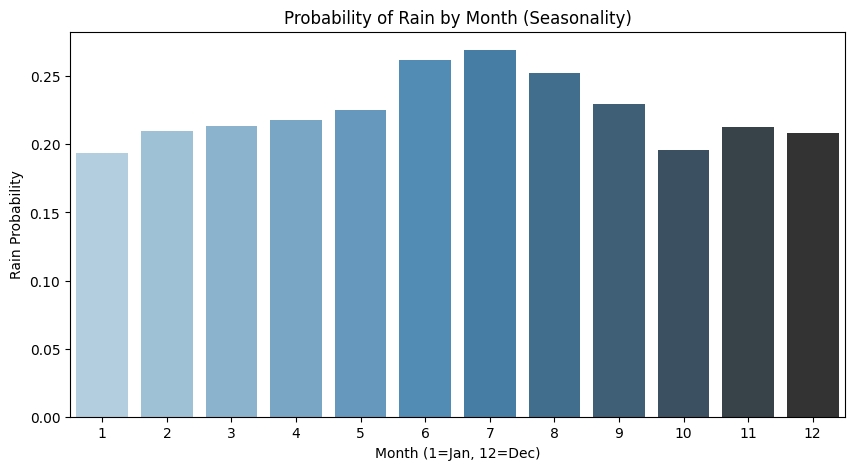

In [ ]:
plt.figure(figsize=(10, 5))
# Ensure RainTomorrow is numeric for the mean calculation
seasonal_rain = df.groupby('Month')['RainTomorrow'].mean()
sns.barplot(x=seasonal_rain.index, y=seasonal_rain.values, hue=seasonal_rain.index, palette="Blues_d", legend=False)
plt.title("Probability of Rain by Month (Seasonality)")
plt.ylabel("Rain Probability")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.show()

FIGURE 4: Wind Gust Analysis

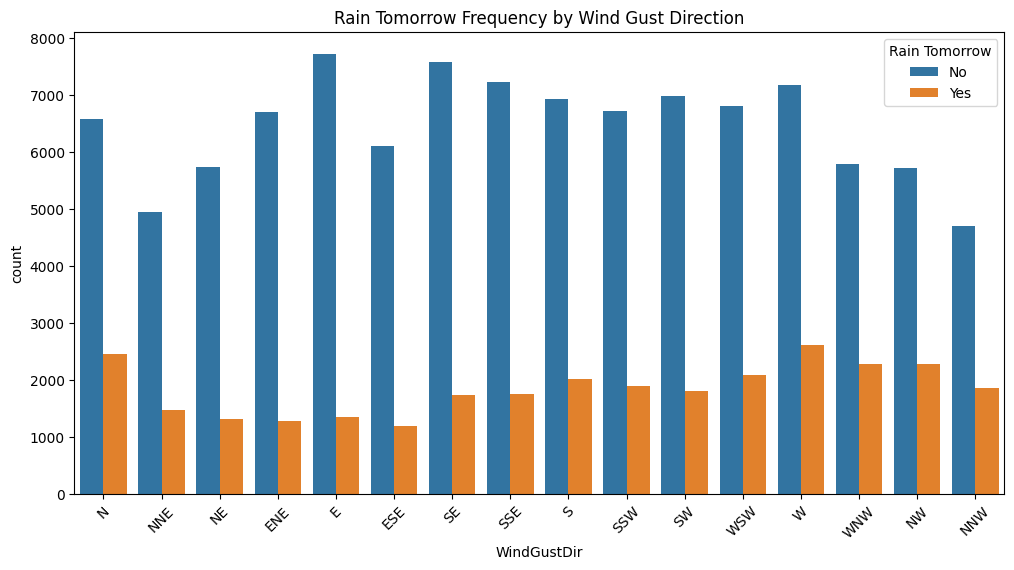

In [ ]:
# Tần suất mưa theo hướng gió (WindGustDir)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='WindGustDir', hue='RainTomorrow',
              order=['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSW','SW','WSW','W','WNW','NW','NNW'])
plt.title("Rain Tomorrow Frequency by Wind Gust Direction")
plt.xticks(rotation=45)
plt.legend(title='Rain Tomorrow', labels=['No', 'Yes'])
plt.show()

FIGURE 5: Rainfall Distribution (Log Scale)

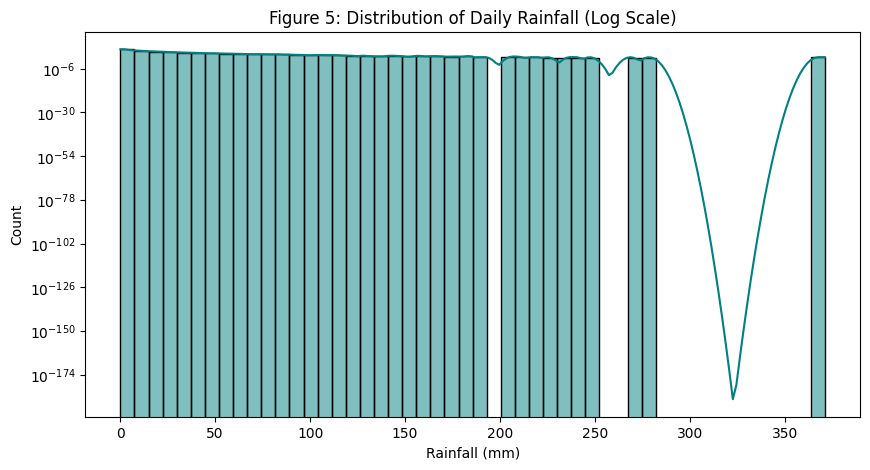

In [ ]:
# Phân phối lượng mưa (chỉ lấy ngày có mưa > 0)
plt.figure(figsize=(10, 5))
if 'Rainfall' in df.columns:
    sns.histplot(df[df['Rainfall'] > 0]['Rainfall'], bins=50, kde=True, color='teal')
    plt.yscale('log') # Log scale vì lượng mưa biến thiên lớn
    plt.title("Figure 5: Distribution of Daily Rainfall (Log Scale)")
    plt.xlabel("Rainfall (mm)")
    plt.show()

FIGURE 6: Interaction Plot (Sunshine vs Humidity)

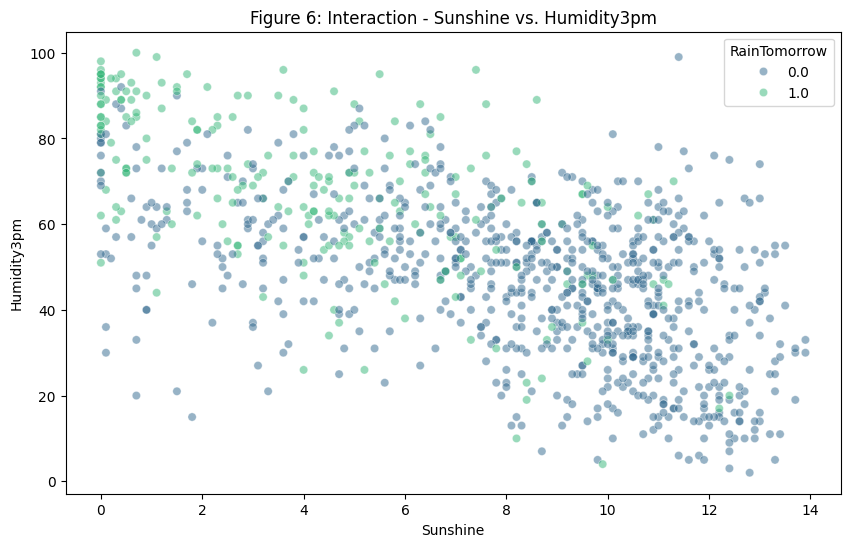

In [ ]:
# Mối quan hệ giữa Nắng, Độ ẩm và Mưa
plt.figure(figsize=(10, 6))
if 'Sunshine' in df.columns and 'Humidity3pm' in df.columns:
    # Lấy mẫu ngẫu nhiên 2000 điểm để vẽ cho nhanh và thoáng
    sample_size = min(len(df), 2000)
    sns.scatterplot(data=df.sample(sample_size), x='Sunshine', y='Humidity3pm',
                    hue='RainTomorrow', alpha=0.5, palette='viridis')
    plt.title("Figure 6: Interaction - Sunshine vs. Humidity3pm")
    plt.show()

In [ ]:
# Cấu hình
pd.set_option('display.max_columns', None)
TIME_STEPS = 14  # Dùng 14 ngày quá khứ để dự báo ngày mai

4. Data Preprocessing

PHẦN 1: XỬ LÝ DỮ LIỆU QUY MÔ LỚN (FULL DATASET)

In [ ]:
print("--- [1/6] Đang tải và xử lý dữ liệu từ toàn bộ 49 địa điểm... ---")

# 1. Load Data
df = pd.read_csv('weatherAUS.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.dropna(subset=['RainTomorrow'], inplace=True) # Bỏ dòng không có nhãn

# 2. Chọn Features
# Model sẽ học quy luật vật lý chung, không phụ thuộc tên địa điểm cụ thể
features = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
            'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
            'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday']

data_subset = df[features + ['RainTomorrow', 'Location', 'Date']].copy()

# 3. Điền dữ liệu thiếu (Imputation) & Encoding
# Tách cột số và cột chữ
num_cols = [c for c in features if data_subset[c].dtype in ['float64', 'int64']]
cat_cols = [c for c in features if data_subset[c].dtype == 'object']

# Điền missing value
imputer_num = SimpleImputer(strategy='mean')
data_subset[num_cols] = imputer_num.fit_transform(data_subset[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
data_subset[cat_cols] = imputer_cat.fit_transform(data_subset[cat_cols])

# Encode Binary (RainToday, RainTomorrow)
le = LabelEncoder()
data_subset['RainToday'] = le.fit_transform(data_subset['RainToday'])
data_subset['RainTomorrow'] = le.fit_transform(data_subset['RainTomorrow'])

# 4. Scaling (Chuẩn hóa về 0-1)
scaler = MinMaxScaler()
feature_data = data_subset[features].values
feature_data_scaled = scaler.fit_transform(feature_data)

# Gán ngược lại để chuẩn bị cắt chuỗi
df_processed = pd.DataFrame(feature_data_scaled, columns=features)
df_processed['RainTomorrow'] = data_subset['RainTomorrow'].values
df_processed['Location'] = data_subset['Location'].values
df_processed['Date'] = data_subset['Date'].values

--- [1/6] Đang tải và xử lý dữ liệu từ toàn bộ 49 địa điểm... ---


PHẦN 2: TẠO CHUỖI THỜI GIAN (STACKING SEQUENCES)

In [ ]:
print("--- [2/6] Đang tạo Sliding Window cho từng thành phố... ---")

def create_dataset_by_location(dataset, time_steps=14):
    X_list, y_list = [], []

    # Nhóm theo địa điểm để đảm bảo tính liên tục của thời gian
    grouped = dataset.groupby('Location')

    for name, group in grouped:
        # Sắp xếp theo ngày trong từng thành phố
        group = group.sort_values('Date')

        # Lấy data (chỉ lấy chỉ số khí tượng, bỏ Location/Date)
        data_values = group[features].values
        target_values = group['RainTomorrow'].values

        # Tạo cửa sổ trượt
        for i in range(len(data_values) - time_steps):
            X_list.append(data_values[i:(i + time_steps)])
            y_list.append(target_values[i + time_steps])

    return np.array(X_list), np.array(y_list)

X_full, y_full = create_dataset_by_location(df_processed, TIME_STEPS)
print(f"Kích thước dữ liệu tổng hợp: {X_full.shape} (Samples, TimeSteps, Features)")

# Chia Train/Test (Shuffle=True ok vì các mẫu là chuỗi độc lập từ nhiều TP)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Tính Class Weight (Để xử lý mất cân bằng dữ liệu cho LSTM/CNN)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights (0: No, 1: Yes): {class_weight_dict}")

--- [2/6] Đang tạo Sliding Window cho từng thành phố... ---
Kích thước dữ liệu tổng hợp: (141507, 14, 13) (Samples, TimeSteps, Features)
Train size: 113205, Test size: 28302
Class Weights (0: No, 1: Yes): {0: np.float64(0.6444698729334608), 1: np.float64(2.2304645939236316)}


5. Training Model

PHẦN 3: MODEL 1 - LOGISTIC REGRESSION (BASELINE)

In [ ]:
print("\n--- [3/6] Training Logistic Regression (Baseline)... ---")

# Logistic Regression cần input 2D. Ta làm phẳng (Flatten) chuỗi thời gian
# Ví dụ: 14 ngày * 13 features = 182 features đầu vào
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

model_logreg = LogisticRegression(solver='liblinear', random_state=42)
model_logreg.fit(X_train_flat, y_train)
print("Logistic Regression Training Done.")


--- [3/6] Training Logistic Regression (Baseline)... ---
Logistic Regression Training Done.


PHẦN 4: MODEL 2 - BIDIRECTIONAL LSTM (MAIN MODEL)

In [ ]:
print("\n--- [4/6] Training Bidirectional LSTM (Main)... ---")

model_lstm = Sequential()
# Bidirectional giúp học cả quá khứ và tương lai trong chuỗi
model_lstm.add(Bidirectional(LSTM(64, return_sequences=True),
                             input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dropout(0.3))
model_lstm.add(LSTM(32, return_sequences=False))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.001)
model_lstm.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train với Class Weight
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=20, # Có thể tăng lên 30-50 nếu máy khỏe
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict, # <--- QUAN TRỌNG
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)


--- [4/6] Training Bidirectional LSTM (Main)... ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.5970 - loss: 0.6599 - val_accuracy: 0.6512 - val_loss: 0.6259
Epoch 2/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.6325 - loss: 0.6365 - val_accuracy: 0.6332 - val_loss: 0.6435
Epoch 3/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.6410 - loss: 0.6294 - val_accuracy: 0.5784 - val_loss: 0.6818
Epoch 4/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.6324 - loss: 0.6278 - val_accuracy: 0.6132 - val_loss: 0.6471
Epoch 5/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6383 - loss: 0.6230 - val_accuracy: 0.7033 - val_loss: 0.5592
Epoch 6/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6431 - loss: 0.6234 - val_accuracy: 0.6556 - val_loss: 0.6132
Epoch 7/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.6420 - loss: 0.6212 - val_accuracy: 0.6108 - val_loss: 0.6547
Epoch 8/20
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.6427 -

PHẦN 5: MODEL 3 - 1D-CNN / TCN (COMPARATIVE MODEL)

In [ ]:
print("\n--- [5/6] Training 1D-CNN (Comparison)... ---")

model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                     input_shape=(X_train.shape[1], X_train.shape[2])))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(50, activation='relu'))
model_cnn.add(Dense(1, activation='sigmoid'))

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)
print("CNN Training Done.")


--- [5/6] Training 1D-CNN (Comparison)... ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Training Done.


6. Compare and evaluate the models.

PHẦN 6: ĐÁNH GIÁ & SO SÁNH (EVALUATION


--- [6/6] Tổng hợp kết quả so sánh ---

BẢNG KẾT QUẢ HIỆU NĂNG:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.7763     0.5168  0.1130    0.1855
1   Bidirectional LSTM    0.6997     0.3848  0.5553    0.4546
2         1D-CNN (TCN)    0.6996     0.3832  0.5459    0.4503


/tmp/ipython-input-720704263.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=results_df, palette='viridis')


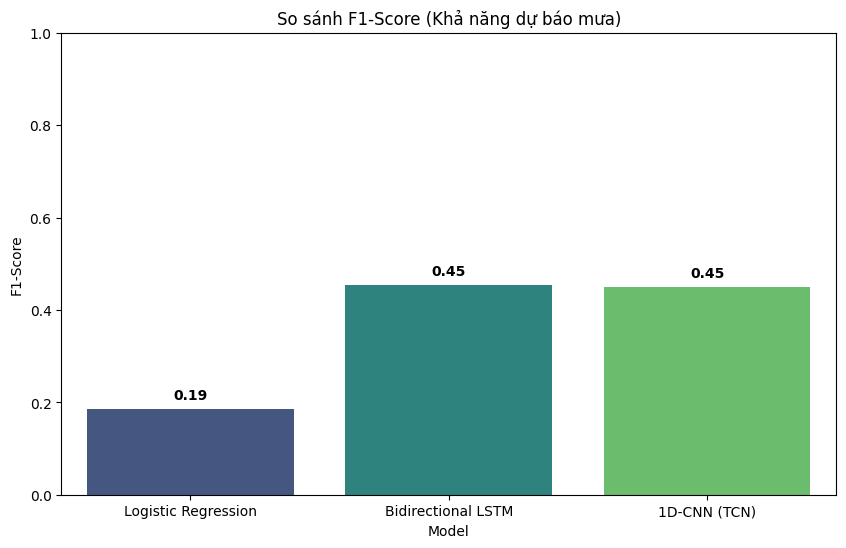

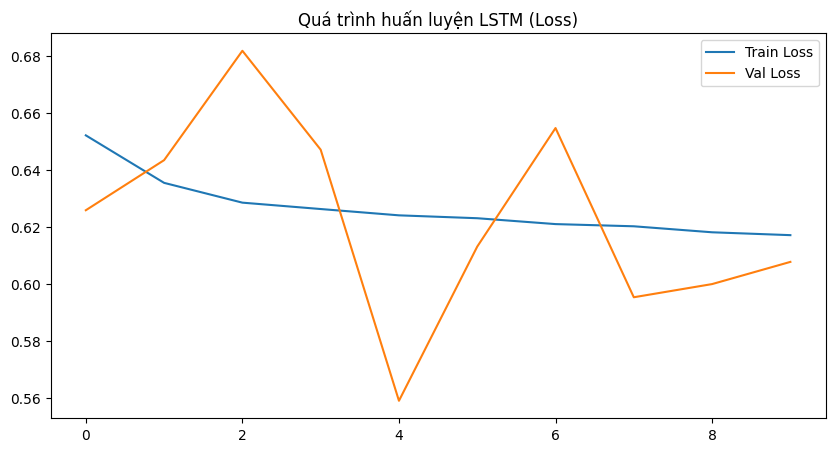


HOÀN THÀNH! Bạn hãy dùng bảng kết quả và biểu đồ trên để đưa vào báo cáo.


In [ ]:
print("\n--- [6/6] Tổng hợp kết quả so sánh ---")

# 1. Dự báo
y_pred_logreg = model_logreg.predict(X_test_flat)

y_pred_lstm_prob = model_lstm.predict(X_test, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype("int32").flatten()

y_pred_cnn_prob = model_cnn.predict(X_test, verbose=0)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype("int32").flatten()

# 2. Tính Metrics
models = ['Logistic Regression', 'Bidirectional LSTM', '1D-CNN (TCN)']
preds = [y_pred_logreg, y_pred_lstm, y_pred_cnn]
results = []

for name, p in zip(models, preds):
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'Recall': recall_score(y_test, p),
        'F1-Score': f1_score(y_test, p)
    })

results_df = pd.DataFrame(results)

# 3. Hiển thị bảng kết quả
print("\nBẢNG KẾT QUẢ HIỆU NĂNG:")
print(results_df.round(4))

# 4. Vẽ biểu đồ so sánh F1-Score
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score', data=results_df, palette='viridis')
plt.title('So sánh F1-Score (Khả năng dự báo mưa)')
plt.ylim(0, 1.0)
for i, v in enumerate(results_df['F1-Score']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()

# 5. Vẽ Loss của LSTM để check Overfitting
plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('Quá trình huấn luyện LSTM (Loss)')
plt.legend()
plt.show()

print("\nHOÀN THÀNH! Bạn hãy dùng bảng kết quả và biểu đồ trên để đưa vào báo cáo.")

In [ ]:
import joblib

# 1. Lưu model LSTM (định dạng Keras)
model_lstm.save('lstm_weather_model.h5')

# 2. Lưu bộ chuẩn hóa Scaler (RẤT QUAN TRỌNG)
# Nếu không có cái này, số liệu nhập từ web (ví dụ 30 độ C) sẽ không khớp với số liệu lúc train (0.5)
joblib.dump(scaler, 'scaler.pkl')

print("Đã lưu xong: lstm_weather_model.h5 và scaler.pkl")

Đã lưu xong: lstm_weather_model.h5 và scaler.pkl
